In [1]:
import zipfile
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# Load the entire images dataset
zip_ref = zipfile.ZipFile("/content/drive/MyDrive/PhD AI/Stomata Project/stomata_images/dataset_intero.zip", 'r')
zip_ref.extractall("/content/tmp")
zip_ref.close()

In [3]:
import numpy as np
import pandas as pd
from skimage import io
from skimage import transform
from skimage.feature import structure_tensor
from skimage.transform import rotate
import matplotlib.pyplot as plt

In [4]:
# LOAD THE DATASET OF DETECTED STOMATA OBTAINED FROM THE NOTEBOOK "yolov8_obb_STOMATA.ipynb"
obb_df = pd.read_csv("/content/drive/MyDrive/PhD AI/Stomata Project/obb_full_dataset_20260719_135800_870220_count_calibrated.csv")
# OPTIONAL: rename columns
obb_df.rename(columns={"confidence": "conf", "center_x": "cx", "center_y": "cy", "width_px": "w_px", "height_px": "h_px", "width_normalized": "w_norm", "height_normalized": "h_norm", "angle_degrees": "angle_deg", "image_width": "orig_w", "image_height": "orig_h"}, inplace=True)
obb_df.head()

,image,detection_id,class_id,class_name,conf,cx,cy,w_px,h_px,w_norm,h_norm,angle_deg,area_px,orig_w,orig_h,split,adopted_confidence_threshold,nms_iou_threshold
0,10.3.4.1.b.1.jpg,0,0,stomata,0.909462,1051.962524,637.057983,25.091455,33.708817,0.019603,0.032919,89.878985,845.803284,1280,1024,full,0.475284,0.7
1,10.3.4.1.b.1.jpg,1,0,stomata,0.908153,880.462891,431.898743,25.642227,29.160225,0.020033,0.028477,89.520721,747.733093,1280,1024,full,0.475284,0.7
2,10.3.4.1.b.1.jpg,2,0,stomata,0.905902,292.563812,429.685486,31.322273,29.055536,0.024471,0.028375,0.368401,910.085449,1280,1024,full,0.475284,0.7
3,10.3.4.1.b.1.jpg,3,0,stomata,0.904577,1094.281860,715.850281,32.029236,23.502747,0.025023,0.022952,0.480722,752.775024,1280,1024,full,0.475284,0.7
4,10.3.4.1.b.1.jpg,4,0,stomata,0.903964,774.515076,431.284668,33.060204,26.198296,0.025828,0.025584,1.775311,866.120972,1280,1024,full,0.475284,0.7


In [5]:
# LOAD THE DATASET OF DETECTED STOMATA OBTAINED FROM THE NOTEBOOK "MAGIC Leaf Veins.ipynb"
stomata_df = pd.read_csv("/content/drive/MyDrive/PhD AI/Stomata Project/stomata_df_251212.csv")
stomata_df.head()

,filename,treat_code,batch,block,plant_number,top/bottom,image_replicate,venation_lengths,interval_lengths,all_lengths,dominant_angle
0,F4.3.4.2.t.1.jpg,F4,3,4,2,t,1.0,[121 40 32 33 33 29 33 30 19 34 39 ...,[28 35 31 33 43 31 42 31 37 35 89 38 32],[-121 28 -40 35 -32 31 -33 33 -33 ...,1.082004
1,275.1.2.3.t.2.jpg,275,1,2,3,t,2.0,[49 83 35 57 61 37 62 51 67 47 40 5],[ 3 39 46 42 41 51 44 34 40 99 26],[-49 3 -83 39 -35 46 -57 42 -61 41 -37 ...,-1.595848
2,F2.4.3.3.t.2.jpg,F2,4,3,3,t,2.0,[47 52 36 41 20 35 65 32 21 28 10 53 42 88 27],[15 33 32 38 79 32 32 38 28 28 33 27 15 16],[-47 15 -52 33 -36 32 -41 38 -20 79 -35 ...,0.847731
3,240.3.3.5.b.1.jpg,240,3,3,5,b,1.0,[37 52 44 18 48 48 72 56 44 47 25 47 61],[31 32 28 29 27 39 35 41 48 35 45 44 45],[ 31 -37 32 -52 28 -44 29 -18 27 -48 39 -...,-2.453241
4,F2.3.4.6.t.1.jpg,F2,3,4,6,t,1.0,[ 3 68 35 50 58 60 67 63 64 104 16],[28 36 43 52 52 73 49 47 33 27],[ -3 28 -68 36 -35 43 -50 52 -58 ...,0.194713


In [8]:
# OPTIONAL: rename columns
stomata_df.rename(columns={"venation_lengths": "vein_lengths"}, inplace=True)
stomata_df.head()

,filename,treat_code,batch,block,plant_number,top/bottom,image_replicate,vein_lengths,interval_lengths,all_lengths,dominant_angle
0,F4.3.4.2.t.1.jpg,F4,3,4,2,t,1.0,[121 40 32 33 33 29 33 30 19 34 39 ...,[28 35 31 33 43 31 42 31 37 35 89 38 32],[-121 28 -40 35 -32 31 -33 33 -33 ...,1.082004
1,275.1.2.3.t.2.jpg,275,1,2,3,t,2.0,[49 83 35 57 61 37 62 51 67 47 40 5],[ 3 39 46 42 41 51 44 34 40 99 26],[-49 3 -83 39 -35 46 -57 42 -61 41 -37 ...,-1.595848
2,F2.4.3.3.t.2.jpg,F2,4,3,3,t,2.0,[47 52 36 41 20 35 65 32 21 28 10 53 42 88 27],[15 33 32 38 79 32 32 38 28 28 33 27 15 16],[-47 15 -52 33 -36 32 -41 38 -20 79 -35 ...,0.847731
3,240.3.3.5.b.1.jpg,240,3,3,5,b,1.0,[37 52 44 18 48 48 72 56 44 47 25 47 61],[31 32 28 29 27 39 35 41 48 35 45 44 45],[ 31 -37 32 -52 28 -44 29 -18 27 -48 39 -...,-2.453241
4,F2.3.4.6.t.1.jpg,F2,3,4,6,t,1.0,[ 3 68 35 50 58 60 67 63 64 104 16],[28 36 43 52 52 73 49 47 33 27],[ -3 28 -68 36 -35 43 -50 52 -58 ...,0.194713


In [9]:
import numpy as np

def get_boundaries_function_per_section(section_lengths, dominant_angle, section,
                                        y_max=1024, y_min=0, x_max=1280, x_min=0):
    """
    section_lengths: 1D array, ordered top->bottom along the rotated image's vertical axis.
                     Vein > 0, intervals < 0. (Measured after rotating by alpha=-dominant_angle.)
    dominant_angle : radians (same one used to produce section_lengths).
    section        : index of the vein to select.
    returns:
      get_y_max(x, _), get_y_min(x, _)  -> y-boundaries in ORIGINAL image at that x.
    """
    # Original image center in *image coords* (y down)
    c_x = (x_min + x_max) / 2.0
    c_y = (y_min + y_max) / 2.0

    # Use the SAME rotation as for measuring lengths
    alpha = -float(dominant_angle)
    sinA, cosA = np.sin(alpha), np.cos(alpha)
    if abs(cosA) < 1e-8:
        raise RuntimeError("Rotation ~90°: switch to solving x from a horizontal band.")

    # v(x,y) = X*sinA + Y*cosA  (vertical coord in the rotated frame, measured downward)
    def v_of(x, y):
        return (x - c_x) * sinA + (y - c_y) * cosA

    # v-range (top/bottom) of the rotated original: evaluate on the 4 corners
    vs = [v_of(x_min, y_min), v_of(x_min, y_max),
          v_of(x_max, y_min), v_of(x_max, y_max)]
    v_min = float(min(vs))
    v_max = float(max(vs))

    # cumulative positions along y' using absolute lengths
    L = np.asarray(section_lengths, dtype=float)
    if section < 0 or section >= len(L):
        raise IndexError("section index out of range.")
    if L[section] <= 0:
        raise ValueError("Selected section is an interval (<=0). Choose a vein (>0).")

    absL = np.abs(L)
    cum = np.cumsum(np.concatenate([[0.0], absL]))  # cum[k]=start, cum[k+1]=end

    # base vein bounds in v
    v0 = v_min + cum[section]
    v1 = v_min + cum[section+1]

    # pad by half of adjacent intervals (if present)
    pad_above = 0.2 * absL[section-1] if (section-1) >= 0 and L[section-1] < 0 else 0.0
    pad_below = 0.2 * absL[section+1] if (section+1) < len(L) and L[section+1] < 0 else 0.0

    v_up  = max(v0 - pad_above, v_min)
    v_low = min(v1 + pad_below, v_max)

    # Invert: from v=const to y(x):  y = c_y + (v - (x-c_x)sinA)/cosA
    def y_from_v_at_x(x, v_const):
        return c_y + (v_const - (x - c_x) * sinA) / cosA

    get_y_min = lambda x, _y: y_from_v_at_x(x, v_up)
    get_y_max = lambda x, _y: y_from_v_at_x(x, v_low)

    return get_y_max, get_y_min



In [10]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


def cluster_and_regress(filename, obb_df, stomata_df, show_result=False):
    stomata = obb_df[obb_df["image"] == filename].reset_index(drop=True)
    section_lengths = stomata_df[stomata_df["filename"] == filename]["all_lengths"].values[0]
    dominant_angle  = float(stomata_df[stomata_df["filename"] == filename]["dominant_angle"].values[0])
    print(dominant_angle)
    print(section_lengths)
    coefs, intercepts = [], []

    # arrays aligned to ALL stomata for visualization
    yerr_lower = np.full(len(stomata), np.nan, dtype=float)
    yerr_upper = np.full(len(stomata), np.nan, dtype=float)

    for i, L in enumerate(section_lengths):
        if L <= 0:
            continue  # skip intervals

        get_y_max, get_y_min = get_boundaries_function_per_section(section_lengths, dominant_angle, i)

        xs, ys = [], []
        for idx, row in stomata.iterrows():
            x = float(row["cx"]); y = float(row["cy"])
            y_min = float(get_y_min(x, y))
            y_max = float(get_y_max(x, y))

            # assign errors ONLY if the point belongs to this vein band
            if y_min <= y <= y_max:
                xs.append(x); ys.append(y)
                yerr_lower[idx] = y - y_min
                yerr_upper[idx] = y_max - y

        if len(xs) == 0:
            continue
        X = np.array(xs).reshape(-1, 1)
        reg = LinearRegression().fit(X, np.array(ys))
        coefs.append(reg.coef_)
        intercepts.append(reg.intercept_)

    if show_result:
        min_cx = float(stomata["cx"].min())
        max_cx = float(stomata["cx"].max())

        plt.figure(figsize=(10,10))
        plt.imshow(io.imread(f"/content/tmp/dataset_intero/{filename}"))
        # plot only points with finite errors
        plt.errorbar(stomata["cx"], stomata["cy"],
                     yerr=np.vstack([yerr_lower, yerr_upper]),
                     fmt="o", c="blue", ecolor="blue", elinewidth=1, capsize=0)

        for a, b in zip(coefs, intercepts):
            a = float(np.ravel(a)[0]); b = float(b)
            x_line = np.array([min_cx, max_cx])
            y_line = a * x_line + b
            plt.plot(x_line, y_line, color="red")
        plt.show()

    return coefs, intercepts



In [11]:
import ast
import re
import pandas as pd # Import pandas for pd.isna

def parse_section_lengths(s):
    if pd.isna(s):
        return []
    if isinstance(s, list):
        return s
    s = str(s).strip()
    # 1) prova literal_eval (caso: "[2, 55, 22, ...]")
    try:
        v = ast.literal_eval(s)
        return list(v)
    except Exception:
        pass
    # 2) fallback: estrai numeri anche se non ci sono virgole (caso: "[ 2 55 22 ... ]")
    nums = re.findall(r'-?\d+(?:\.\d+)?', s)

    return [int(x) for x in nums]

stomata_df["all_lengths"] = stomata_df["all_lengths"].apply(parse_section_lengths)

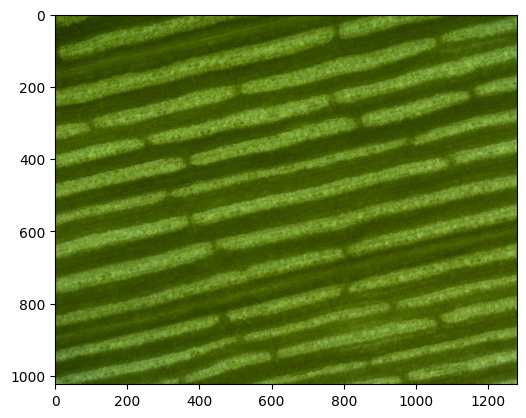

In [13]:
plt.imshow(io.imread("/content/tmp/dataset_intero/62.2.4.1.b.2.jpg"))

In [14]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from skimage import io

# ---------- helpers ----------
def build_vein_bands_v(section_lengths, dominant_angle,
                           x_min=0, x_max=1280, y_min=0, y_max=1024, pad_frac=0.5):
    c_x = (x_min + x_max) / 2.0
    c_y = (y_min + y_max) / 2.0
    alpha = float(dominant_angle)           # CCW-positive
    sinA, cosA = np.sin(alpha), np.cos(alpha)
    if abs(cosA) < 1e-8:
        raise RuntimeError("Rotation ~90°; switch to x-boundaries.")

    v_of = lambda x,y: (x - c_x)*sinA + (y - c_y)*cosA
    vs = [v_of(x_min, y_min), v_of(x_min, y_max),
          v_of(x_max, y_min), v_of(x_max, y_max)]
    v_min, v_max = float(min(vs)), float(max(vs))

    L = np.asarray(section_lengths, dtype=float)
    absL = np.abs(L)
    cum = np.cumsum(np.concatenate([[0.0], absL]))

    ven_idx = np.where(L < 0)[0]
    v_up  = np.empty(len(ven_idx))
    v_low = np.empty(len(ven_idx))
    for j, k in enumerate(ven_idx):
        v0 = v_min + cum[k]
        v1 = v_min + cum[k+1]
        pad_above = pad_frac*absL[k-1] if (k-1)>=0    and L[k-1] > 0 else 0.0
        pad_below = pad_frac*absL[k+1] if (k+1)<len(L) and L[k+1] > 0 else 0.0
        v_up[j]  = max(v0 - pad_above, v_min)
        v_low[j] = min(v1 + pad_below, v_max)

    return ven_idx, v_up, v_low, dict(L=L, absL=absL, cum=cum, v_min=v_min, v_max=v_max, sinA=sinA, cosA=cosA, c_x=c_x, c_y=c_y)

def y_from_v_at_x(x, v_const, H):
    sinA, cosA, c_x, c_y = H["sinA"], H["cosA"], H["c_x"], H["c_y"]
    return c_y + (v_const - (x - c_x)*sinA)/cosA

def x_from_v_at_y(y, v_const, H):
    sinA, cosA, c_x, c_y = H["sinA"], H["cosA"], H["c_x"], H["c_y"]
    return c_x + ( (v_const - (y - c_y)*cosA) / sinA )

def segment_for_v(v_const, H, W, Ht):
    """Ritorna due punti (x1,y1), (x2,y2) della retta v=v_const ritagliata al rettangolo [0,W]x[0,Ht].
       Se non interseca, ritorna None."""
    sinA, cosA = H["sinA"], H["cosA"]
    pts = []

    # Intersection with x=0 and x=W
    for x in (0.0, float(W)):
        if abs(cosA) > 1e-12:
            y = y_from_v_at_x(x, v_const, H)
            if 0.0 <= y <= float(Ht): pts.append((x, y))

    # Intersections with y=0 and y=H
    for y in (0.0, float(Ht)):
        if abs(sinA) > 1e-12:
            x = x_from_v_at_y(y, v_const, H)
            if 0.0 <= x <= float(W): pts.append((x, y))

    if len(pts) < 2:
        return None

    P = np.array(pts, float)
    d2 = ((P[None,:]-P[:,None])**2).sum(-1)
    i,j = np.unravel_index(np.argmax(d2), d2.shape)
    return (P[i,0],P[i,1]), (P[j,0],P[j,1])


# ---------- main: compute error bars (to half-interval edges) + true regressions ----------
def cluster_and_regress(filename, obb_df, stomata_df, show_result=False, pad_frac=0.5):
    stomata = obb_df[obb_df["image"] == filename].reset_index(drop=True)
    row = stomata_df[stomata_df["filename"] == filename].iloc[0]
    section_lengths = row["all_lengths"]
    dominant_angle  = float(row["dominant_angle"])

    ven_idx, v_up, v_low, H = build_vein_bands_v(section_lengths, dominant_angle, pad_frac=pad_frac)
    sinA, cosA, c_x, c_y = H["sinA"], H["cosA"], H["c_x"], H["c_y"]

    Ht, W = 1024, 1280

    Xs = stomata["cx"].to_numpy(float)
    Ys = stomata["cy"].to_numpy(float)
    V  = (Xs - c_x)*sinA + (Ys - c_y)*cosA

    # assign each point strictly to a vein if inside
    assign = np.full(len(stomata), -1, int)
    yerr_lower = np.full(len(stomata), np.nan, float)
    yerr_upper = np.full(len(stomata), np.nan, float)

    # --- Positive intervals (bundles) ---
    L, absL, cum, v_min, v_max = H["L"], H["absL"], H["cum"], H["v_min"], H["v_max"]
    pos_idx = np.where(L > 0)[0]
    pos_up  = np.empty(len(pos_idx))
    pos_low = np.empty(len(pos_idx))
    for j, k in enumerate(pos_idx):
        v0 = v_min + cum[k]
        v1 = v_min + cum[k+1]
        pad_from_prev = pad_frac*absL[k-1] if (k-1)>=0     and L[k-1] < 0 else 0.0
        pad_from_next = pad_frac*absL[k+1] if (k+1)<len(L) and L[k+1] < 0 else 0.0
        pos_up[j]  = max(v0 + pad_from_prev, v_min)
        pos_low[j] = min(v1 - pad_from_next, v_max)

    # --- Lenghts of veins and bundles ---
    band_lengths = []
    band_lengths_pos = []

    for j in range(len(pos_idx)):
        v_mid = 0.5*(pos_up[j] + pos_low[j])
        seg = segment_for_v(v_mid, H, W, Ht)
        if seg is None:
            band_lengths_pos.append(0.0)
        else:
            (x1,y1),(x2,y2) = seg
            band_lengths_pos.append(float(np.hypot(x2-x1, y2-y1)))

    coefs, intercepts = [], []

    for j, k in enumerate(ven_idx):
        inside = (V >= v_up[j]) & (V <= v_low[j])
        assign[inside] = k
        # error bars to the *half-interval* edges (converted to vertical pixels)
        yerr_lower[inside] = (V[inside] - v_up[j])  / abs(cosA)
        yerr_upper[inside] = (v_low[j] - V[inside]) / abs(cosA)

        # regressions per vein using only assigned points
        idx = (assign == k)
        if not np.any(idx) or len(Xs[idx])==1:
            continue
        X = Xs[idx].reshape(-1,1)
        y = Ys[idx]

        coefs.append(np.tan(dominant_angle))
        beta0 = y.mean() - np.tan(dominant_angle) * X.mean()
        intercepts.append(beta0)

        v_mid = 0.5*(v_up[j] + v_low[j])
        seg = segment_for_v(v_mid, H, W, Ht)
        if seg is None:
            band_lengths.append(0.0)
        else:
            (x1,y1),(x2,y2) = seg
            band_lengths.append(float(np.hypot(x2-x1, y2-y1)))

    print(band_lengths)
    print(band_lengths_pos)

    if show_result: #if True, plot the result on the image
        img = io.imread(f"/content/tmp/dataset_intero/{filename}")
        Ht, W = img.shape[0], img.shape[1]
        plt.figure(figsize=(10,10))
        plt.imshow(img)

        plt.errorbar(Xs, Ys, yerr=np.vstack([yerr_lower, yerr_upper]),
                    fmt="o", c="blue", ecolor="blue", elinewidth=1, capsize=0)

        for j in range(len(ven_idx)):
            for v_const in (v_up[j], v_low[j]):
                seg = segment_for_v(v_const, H, W, Ht)
                if seg is not None:
                    (x1,y1),(x2,y2) = seg
                    plt.plot([x1,x2],[y1,y2], color="red", linewidth=1)

        for a, b in zip(coefs, intercepts):
            m = float(np.ravel(a)[0]); q = float(b)

            pts = []

            for x in (0.0, float(W)):
                y = m*x + q
                if 0.0 <= y <= float(Ht): pts.append((x,y))

            if abs(m) > 1e-12:
                for y in (0.0, float(Ht)):
                    x = (y - q)/m
                    if 0.0 <= x <= float(W): pts.append((x,y))

            if len(pts) >= 2:
                P = np.array(pts, float)
                d2 = ((P[None,:]-P[:,None])**2).sum(-1)
                i,j = np.unravel_index(np.argmax(d2), d2.shape)
                (x1,y1),(x2,y2) = (P[i,0],P[i,1]), (P[j,0],P[j,1])
                plt.plot([x1,x2],[y1,y2], linewidth=2.5, color="orange")

        plt.xlim(0, W); plt.ylim(Ht, 0)
        plt.show()



In [15]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import math

def y_from_v_at_x(x, v_const, H):
    sinA, cosA, c_x, c_y = H["sinA"], H["cosA"], H["c_x"], H["c_y"]
    return c_y + (v_const - (x - c_x)*sinA)/cosA

def x_from_v_at_y(y, v_const, H):
    sinA, cosA, c_x, c_y = H["sinA"], H["cosA"], H["c_x"], H["c_y"]
    return c_x + ( (v_const - (y - c_y)*cosA) / sinA )

def segment_for_v(v_const, H, W, Ht):
    """Return points (x1,y1), (x2,y2) of line v=v_const cut at rectangle [0,W]x[0,Ht].
       If it does not intersect, return None."""
    sinA, cosA = H["sinA"], H["cosA"]
    pts = []

    # Intersection with x=0 and x=W
    for x in (0.0, float(W)):
        if abs(cosA) > 1e-12:
            y = y_from_v_at_x(x, v_const, H)
            if 0.0 <= y <= float(Ht): pts.append((x, y))

    # Intersections with y=0 e y=H
    for y in (0.0, float(Ht)):
        if abs(sinA) > 1e-12:
            x = x_from_v_at_y(y, v_const, H)
            if 0.0 <= x <= float(W): pts.append((x, y))

    if len(pts) < 2:
        return None

    P = np.array(pts, float)
    d2 = ((P[None,:]-P[:,None])**2).sum(-1)
    i,j = np.unravel_index(np.argmax(d2), d2.shape)
    return (P[i,0],P[i,1]), (P[j,0],P[j,1])


def build_interval_bands_v(section_lengths, dominant_angle_deg,
                           x_min=0, x_max=1280, y_min=0, y_max=1024, pad_frac=0.5):
    c_x = (x_min + x_max) / 2.0
    c_y = (y_min + y_max) / 2.0

    # alpha in radians
    alpha = np.deg2rad(float(dominant_angle_deg))  # CCW-positive
    sinA, cosA = np.sin(alpha), np.cos(alpha)

    if abs(cosA) < 1e-8:
        raise RuntimeError("Rotation ~90°; switch to x-boundaries.")

    v_of = lambda x,y: (x - c_x)*sinA + (y - c_y)*cosA
    vs = [v_of(x_min, y_min), v_of(x_min, y_max),
          v_of(x_max, y_min), v_of(x_max, y_max)]
    v_min, v_max = float(min(vs)), float(max(vs))

    L = np.asarray(section_lengths, dtype=float)
    absL = np.abs(L)
    cum = np.cumsum(np.concatenate([[0.0], absL]))

    int_idx = np.where(L > 0)[0]
    v_up  = np.empty(len(int_idx))
    v_low = np.empty(len(int_idx))
    for j, k in enumerate(int_idx):
        v0 = v_min + cum[k]
        v1 = v_min + cum[k+1]
        pad_above = pad_frac*absL[k-1] if (k-1)>=0    and L[k-1] < 0 else 0.0
        pad_below = pad_frac*absL[k+1] if (k+1)<len(L) and L[k+1] < 0 else 0.0
        v_up[j]  = max(v0 - pad_above, v_min)
        v_low[j] = min(v1 + pad_below, v_max)

    return int_idx, v_up, v_low, dict(
        L=L, absL=absL, cum=cum, v_min=v_min, v_max=v_max,
        sinA=sinA, cosA=cosA, c_x=c_x, c_y=c_y,
        dominant_angle_deg=float(dominant_angle_deg),
        alpha_rad=alpha
    )



def build_bands_v_for_sign(all_lengths, dominant_angle_deg, target_sign,
                           x_min=0, x_max=1280, y_min=0, y_max=1024, pad_frac=0.5):
    """
    target_sign = -1 for intervals (L<0), +1 for veins (L>0)
    Padding is taken from adjacent segments of the opposite sign.
    """
    c_x = (x_min + x_max) / 2.0
    c_y = (y_min + y_max) / 2.0

    alpha = np.deg2rad(float(dominant_angle_deg))
    sinA, cosA = np.sin(alpha), np.cos(alpha)

    v_of = lambda x,y: (x - c_x)*sinA + (y - c_y)*cosA
    vs = [v_of(x_min, y_min), v_of(x_min, y_max),
          v_of(x_max, y_min), v_of(x_max, y_max)]
    v_min, v_max = float(min(vs)), float(max(vs))

    L = np.asarray(all_lengths, float)
    absL = np.abs(L)
    cum = np.cumsum(np.concatenate([[0.0], absL]))

    if target_sign < 0:
        idx = np.where(L < 0)[0]   # veins
        neighbor_ok = lambda x: x > 0
    else:
        idx = np.where(L > 0)[0]   # bundles
        neighbor_ok = lambda x: x < 0

    v_up = np.empty(len(idx), float)
    v_low = np.empty(len(idx), float)

    for j, k in enumerate(idx):
        v0 = v_min + cum[k]
        v1 = v_min + cum[k+1]

        pad_above = pad_frac*absL[k-1] if (k-1) >= 0     and neighbor_ok(L[k-1]) else 0.0
        pad_below = pad_frac*absL[k+1] if (k+1) < len(L) and neighbor_ok(L[k+1]) else 0.0

        v_up[j]  = max(v0 - pad_above, v_min)
        v_low[j] = min(v1 + pad_below, v_max)

    H = dict(sinA=sinA, cosA=cosA, c_x=c_x, c_y=c_y, v_min=v_min, v_max=v_max, L=L, absL=absL, cum=cum)
    return idx, v_up, v_low, H




def band_midline_lengths(v_up, v_low, H, W, Ht):
    v_mid = 0.5 * (v_up + v_low)
    lengths = []
    for vm in v_mid:
        seg = segment_for_v(vm, H, W, Ht)
        if seg is None:
            lengths.append(0.0)
        else:
            (x1,y1),(x2,y2) = seg
            lengths.append(float(np.hypot(x2-x1, y2-y1)))
    return np.asarray(lengths, float)



# ------------------------------------------------------------
# SAgg / SEve utilities (your code, unchanged except math import)
# ------------------------------------------------------------
def pairwise_dists(points):
    """Matrice di distanze euclidee."""
    points = np.asarray(points, dtype=float)
    diff = points[:, None, :] - points[None, :, :]
    d2 = np.sum(diff**2, axis=-1)
    return np.sqrt(d2)

def SAgg(points, area=None):
    """
    Stomatal aggregation index (Liu et al. 2021, da Clark–Evans).
    points : (N,2) array di (x,y).
    area   : area totale del campo (stessa unità delle coordinate).
    """
    points = np.asarray(points, dtype=float)
    n = len(points)
    if n < 2:
        return math.nan

    D = pairwise_dists(points)
    np.fill_diagonal(D, np.inf)
    nn = D.min(axis=1)
    d_bar = nn.mean()

    if area is None:
        xs, ys = points[:, 0], points[:, 1]
        area = (xs.max() - xs.min()) * (ys.max() - ys.min())
    if area <= 0:
        return math.nan

    lam = n / area
    d_poisson = 1.0 / (2.0 * math.sqrt(lam))  # atteso Poisson
    return d_bar / d_poisson

def MST_edge_lengths(points):
    """Lunghezze degli archi della MST (Prim)."""
    points = np.asarray(points, dtype=float)
    n = len(points)
    if n <= 1:
        return np.array([])

    D = pairwise_dists(points)
    visited = np.zeros(n, dtype=bool)
    visited[0] = True
    edge_lengths = []

    dist_to_tree = D[0].copy()
    dist_to_tree[0] = np.inf

    for _ in range(n - 1):
        j = np.argmin(dist_to_tree)
        edge_lengths.append(dist_to_tree[j])
        visited[j] = True
        new_d = D[j]
        dist_to_tree = np.where(new_d < dist_to_tree, new_d, dist_to_tree)
        dist_to_tree[visited] = np.inf

    return np.array(edge_lengths)

def SEve(points):
    """
    Stomatal Evenness (SEve) come in Liu et al. 2021.
    """
    points = np.asarray(points, dtype=float)
    n = len(points)
    if n < 3:
        return math.nan

    D = MST_edge_lengths(points)
    total = D.sum()
    if total <= 0:
        return math.nan

    PD = D / total
    ideal = 1.0 / (n - 1)  # tutti i rami uguali
    num = np.sum(np.minimum(PD, ideal)) - ideal
    den = 1.0 - ideal
    return num / den if den > 0 else math.nan


# ------------------------------------------------------------
# cluster_and_regress (integrated)
# ------------------------------------------------------------
def cluster_and_regress(filename, obb_df, stomata_df, show_result=False, pad_frac=0.5, area_mm=None):
    """
    Params:
    - filename: image filename
    - obb_df: obb dataset of stomata
    - stomata_df: dataset with widths of veins
    - show_results: if True, print the results on the image
    - pad_frac: ratio of intervals padding to account for non perfectly straight veins
    - area: if specified, then measures in stomata_df are considered to be in mm and not in px

    Returns:
    - vein_density
    - interval_density
    - leaf_flip_rate
    - leaf_acf1_signed
    - leaf_curvature
    - SAgg
    - SEve
    """
    stomata = obb_df[obb_df["image"] == filename].reset_index(drop=True)
    row = stomata_df[stomata_df["filename"] == filename].iloc[0]
    section_lengths = row["all_lengths"]
    dominant_angle = float(row["dominant_angle"])

    Ht, W = 1024, 1280

    ven_idx, vup_ven, vlo_ven, Hven = build_bands_v_for_sign(section_lengths, dominant_angle, target_sign=-1,
                                                            x_min=0, x_max=W, y_min=0, y_max=Ht, pad_frac=pad_frac)
    int_idx, vup_int, vlo_int, Hint = build_bands_v_for_sign(section_lengths, dominant_angle, target_sign=+1,
                                                            x_min=0, x_max=W, y_min=0, y_max=Ht, pad_frac=pad_frac)

    H = Hint
    # slope for regression (m = tan(theta) with theta in radians)
    m = -float(np.tan(np.deg2rad(dominant_angle)))

    sinA, cosA, c_x, c_y = H["sinA"], H["cosA"], H["c_x"], H["c_y"]

    Xs = stomata["cx"].to_numpy(float)
    Ys = stomata["cy"].to_numpy(float)

    V  = (Xs - c_x)*sinA + (Ys - c_y)*cosA
    U  = (Xs - c_x)*cosA - (Ys - c_y)*sinA

    n = len(Xs)

    # ------------------------------------------------------------
    # CONSISTENT ASSIGNMENT (one-shot)
    # If overlaps exist, choose the band whose midline is closest in v.
    # ------------------------------------------------------------
    v_mid = 0.5 * (vup_int + vlo_int)                      # shape (B,)
    candidates = (V[:, None] >= vup_int[None, :]) & (V[:, None] <= vlo_int[None, :])  # (n,B)
    dist = np.abs(V[:, None] - v_mid[None, :])        # (n,B)
    dist[~candidates] = np.inf

    best = np.argmin(dist, axis=1)                    # (n,)
    has = np.isfinite(dist[np.arange(n), best])       # (n,)

    assign = np.full(n, -1, int)
    assign[has] = int_idx[best[has]]                  # store actual k (from int_idx)

    # ------------------------------------------------------------
    # Error bars (computed using the band chosen for each point)
    # ------------------------------------------------------------
    yerr_lower = np.full(n, np.nan, float)
    yerr_upper = np.full(n, np.nan, float)

    for j, k in enumerate(int_idx):
        idx = (assign == k)
        if not np.any(idx):
            continue
        yerr_lower[idx] = (V[idx] - vup_int[j])  / abs(cosA)
        yerr_upper[idx] = (vlo_int[j] - V[idx]) / abs(cosA)

    # ------------------------------------------------------------
    # Band lengths
    # ------------------------------------------------------------
    # lengths in pixels (midline segments)
    vein_lengths_px = band_midline_lengths(vup_ven, vlo_ven, Hven, W, Ht)
    interval_lengths_px = band_midline_lengths(vup_int, vlo_int, Hint, W, Ht)

    # densities in px^-1 (length/area)
    area_px2 = float(W * Ht)
    vein_density_px = vein_lengths_px.sum() / area_px2
    interval_density_px = interval_lengths_px.sum() / area_px2

    # ------------------------------------------------------------
    # Intercepts computed AFTER final assignment
    # ------------------------------------------------------------
    intercepts_per_band = np.full(len(int_idx), np.nan, float)

    for j, k in enumerate(int_idx):
        idx = (assign == k)
        if np.sum(idx) >= 2:
            intercepts_per_band[j] = float(Ys[idx].mean() - m * Xs[idx].mean())

    # ------------------------------------------------------------
    # Per-band metrics: flip_rate, ACF(1) signed, curvature
    # ------------------------------------------------------------
    flip_rates = np.full(len(int_idx), np.nan, float)
    acf1_signed = np.full(len(int_idx), np.nan, float)
    curvatures = np.full(len(int_idx), np.nan, float)
    counts = np.zeros(len(int_idx), int)
    eff_sign_counts = np.zeros(len(int_idx), int)

    for j, k in enumerate(int_idx):
        idx = (assign == k)
        counts[j] = int(np.sum(idx))
        if counts[j] < 2 or not np.isfinite(intercepts_per_band[j]):
            continue

        # residuals, sorted along band using U
        r = Ys[idx] - (m * Xs[idx] + intercepts_per_band[j])
        u = U[idx]
        order = np.argsort(u)
        r = r[order]

        # flip rate on signs
        s = np.sign(r)
        s = s[s != 0]
        eff_sign_counts[j] = len(s)
        if len(s) >= 2:
            flip_rates[j] = np.sum(s[:-1] != s[1:]) / (len(s) - 1)

        # ACF(1) signed on residuals
        if len(r) >= 3 and np.std(r) > 0:
            acf1_signed[j] = float(np.corrcoef(r[:-1], r[1:])[0, 1])

        # curvature on normalized residuals
        if len(r) >= 3:
            r_norm = r / (np.std(r) + 1e-8)
            curvatures[j] = float(np.mean(np.abs(r_norm[2:] - 2*r_norm[1:-1] + r_norm[:-2])))

    # ------------------------------------------------------------
    # Leaf-level aggregation (single numbers)
    # ------------------------------------------------------------
    # flip rate: weight by number of adjacent sign-pairs
    w_flip = np.maximum(eff_sign_counts - 1, 0).astype(float)
    mask_f = np.isfinite(flip_rates) & (w_flip > 0)
    leaf_flip_rate = (np.sum(flip_rates[mask_f] * w_flip[mask_f]) / np.sum(w_flip[mask_f])) if np.any(mask_f) else np.nan

    # acf(1): weight by number of adjacent residual pairs
    w_acf = np.maximum(counts - 1, 0).astype(float)
    mask_a = np.isfinite(acf1_signed) & (w_acf > 0)
    leaf_acf1_signed = (np.sum(acf1_signed[mask_a] * w_acf[mask_a]) / np.sum(w_acf[mask_a])) if np.any(mask_a) else np.nan

    # curvature: weight by number of second-differences (triples)
    w_curv = np.maximum(counts - 2, 0).astype(float)
    mask_c = np.isfinite(curvatures) & (w_curv > 0)
    leaf_curvature = (np.sum(curvatures[mask_c] * w_curv[mask_c]) / np.sum(w_curv[mask_c])) if np.any(mask_c) else np.nan


    # SAgg / SEve on whole leaf
    pts = np.column_stack([Xs, Ys])
    leaf_area_px = float(W * Ht)
    leaf_SAgg = SAgg(pts, area=leaf_area_px)
    leaf_SEve = SEve(pts)

    # ------------------------------------------------------------
    # Plot (regressions only where intercept exists)
    # ------------------------------------------------------------
    if show_result:
        img = io.imread(f"/content/tmp/dataset_intero/{filename}")
        Ht, W = img.shape[0], img.shape[1]
        plt.figure(figsize=(10,10))
        plt.imshow(img)

        plt.errorbar(
            Xs, Ys, yerr=np.vstack([yerr_lower, yerr_upper]),
            fmt="o", c="blue", ecolor="blue", elinewidth=1, capsize=0
        )

        # boundaries
        for j in range(len(int_idx)):
            for v_const in (vup_int[j], vlo_int[j]):
                seg = segment_for_v(v_const, H, W, Ht)
                if seg is not None:
                    (x1,y1),(x2,y2) = seg
                    plt.plot([x1,x2],[y1,y2], color="red", linewidth=1)

        # regression lines (only for valid intercepts)
        for j in range(len(int_idx)):
            b = intercepts_per_band[j]
            if not np.isfinite(b):
                continue

            pts_line = []
            for x in (0.0, float(W)):
                y = m*x + b
                if 0.0 <= y <= float(Ht):
                    pts_line.append((x,y))
            if abs(m) > 1e-12:
                for y in (0.0, float(Ht)):
                    x = (y - b)/m
                    if 0.0 <= x <= float(W):
                        pts_line.append((x,y))

            if len(pts_line) >= 2:
                P = np.array(pts_line, float)
                d2 = ((P[None,:]-P[:,None])**2).sum(-1)
                i,jj = np.unravel_index(np.argmax(d2), d2.shape)
                (x1,y1),(x2,y2) = (P[i,0],P[i,1]), (P[jj,0],P[jj,1])
                plt.plot([x1,x2],[y1,y2], linewidth=2.5, color="orange")

        plt.xlim(0, W); plt.ylim(Ht, 0)
        plt.show()

    return {
        "vein_density": vein_density_px,
        "interval_density": interval_density_px,
        "leaf_flip_rate": leaf_flip_rate,
        "leaf_acf1_signed": leaf_acf1_signed,
        "leaf_curvature": leaf_curvature,
        "SAgg": leaf_SAgg,
        "SEve": leaf_SEve,
    }


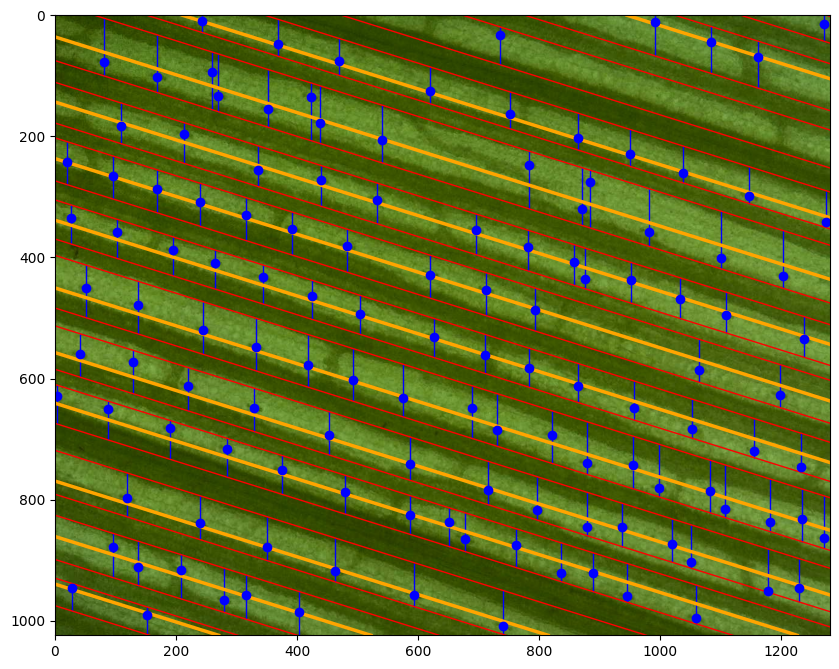

{'vein_density': np.float64(0.010155144012251245),
 'interval_density': np.float64(0.01015326919593666),
 'leaf_flip_rate': np.float64(0.3565217391304348),
 'leaf_acf1_signed': np.float64(0.36619368140029107),
 'leaf_curvature': np.float64(1.425371808430428),
 'SAgg': np.float64(1.5368977697250725),
 'SEve': np.float64(0.9161872995443321)}

In [17]:
cluster_and_regress("108.1.3.5.b.1.jpg", obb_df, stomata_df, pad_frac=0.2, show_result=True)

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# Process images and extract data
def process_images_and_create_csv(output_csv_path):

    stomata_df_2 = stomata_df.copy()

    stomata_df_2["vein_density"]=None
    stomata_df_2["interval_density"]=None
    stomata_df_2["leaf_flip_rate"]=None
    stomata_df_2["leaf_acf1_signed"]=None
    stomata_df_2["leaf_curvature"]=None
    stomata_df_2["SAgg"]=None
    stomata_df_2["SEve"]=None

    root_dir = "/content/tmp"

    # Create a progress bar for files in THIS folder
    for index, row in tqdm(stomata_df_2.iterrows(), desc=f"Processing images..."):
        try:
            results = cluster_and_regress(row["filename"], obb_df, stomata_df, pad_frac=0.2)
            stomata_df_2["vein_density"][index]=results["vein_density"]
            stomata_df_2["interval_density"][index]=results["interval_density"]
            stomata_df_2["leaf_flip_rate"][index]=results["leaf_flip_rate"]
            stomata_df_2["leaf_acf1_signed"][index]=results["leaf_acf1_signed"]
            stomata_df_2["leaf_curvature"][index]=results["leaf_curvature"]
            stomata_df_2["SAgg"][index]=results["SAgg"]
            stomata_df_2["SEve"][index]=results["SEve"]

        except Exception as e:
            print(f"\nError processing image {row["filename"]}: {e}")

    # Create DataFrame
    stomata_df_2.to_csv(output_csv_path, index=False)

In [ ]:
import warnings
warnings.filterwarnings('ignore')


process_images_and_create_csv("/content/drive/MyDrive/PhD AI/Stomata Project/stomata_df_complete_260720_count_calibrated.csv")

Processing images...: 8072it [10:35, 12.69it/s]
